In [1]:
# ============================================================
# [0] 🔑 PCA 실습용 3D 데이터 생성
# ============================================================
# 💡 차원 축소(Dimensionality Reduction)란?
# - 고차원 데이터를 저차원으로 변환하면서 핵심 정보 유지
# - "차원의 저주" 해결, 시각화, 계산 속도 향상, 노이즈 제거 등에 활용
#
# 📌 데이터 특징:
# - 60개 샘플, 3차원 공간
# - 사실은 2D 평면에 가까운 분포 (살짝 두꺼운 팬케이크 모양!)
# - 노이즈 추가, 회전, 이동 → 실제 데이터처럼 만듦
#
# 💡 이 데이터로 보여줄 것: "3D인 척하지만 실제로는 2D" → PCA로 발견 가능
# ============================================================

# 데이터셋 생성을 위한 추가 코드
import numpy as np
from scipy.spatial.transform import Rotation

m = 60
X = np.zeros((m, 3)) # 3D 데이터 초기화
np.random.seed(42)
angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi # 고르지 않은 분포
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5 # 타원형
X += 0.28 * np.random.randn(m, 3) # 노이즈 추가
X = Rotation.from_rotvec([np.pi / 29, -np.pi / 20, np.pi / 4]).apply(X)
X += [0.2, 0, 0.2] # 약간 이동

In [2]:
# ============================================================
# [1] 🔑 SVD(특이값 분해)로 직접 PCA 구현 - 원리 이해!
# ============================================================
# 💡 PCA의 핵심 알고리즘:
# 1. 데이터 중앙 정렬 (평균 빼기) - 반드시 필요!
# 2. SVD: X = U·Σ·V^T 로 분해
# 3. V^T의 행들이 "주성분(principal component)"
#
# 📌 주성분이란?
# - 데이터의 "분산이 가장 큰 방향"
# - c1: 첫 번째 주성분 (가장 중요한 축)
# - c2: 두 번째 주성분 (c1과 수직이며 다음으로 분산 큰 축)
#
# 💡 데이터 중앙 정렬이 필수인 이유:
# - SVD는 원점 기준 분해
# - 중앙 정렬 안 하면 첫 주성분이 "평균 방향"으로 가버림
# ============================================================

X_centered = X - X.mean(axis=0)
U, s, Vt = np.linalg.svd(X_centered)
c1 = Vt[0]
c2 = Vt[1]

In [3]:
# ============================================================
# [2] 💡 2개의 주성분으로 데이터를 2차원에 투영
# ============================================================
# - W2: 처음 2개 주성분을 열로 묶은 투영 행렬 (3x2)
# - X2D = X_centered @ W2: 3D 데이터를 2D 평면에 사영(projection)
# - 결과: 정보 손실 최소화하면서 차원 축소 완료!
# ============================================================

W2 = Vt[:2].T
X2D = X_centered @ W2

In [4]:
# ============================================================
# [3] 🔑 사이킷런 PCA - 위의 모든 과정을 한 줄로!
# ============================================================
# 💡 사이킷런의 PCA는 내부적으로:
# - 자동으로 중앙 정렬 (mean 빼기)
# - SVD 기반 계산
# - fit_transform: 학습 + 변환 한번에
#
# 📌 매개변수:
# - n_components=2: 2차원으로 축소
#
# 💡 [1]~[2]에서 직접 한 작업과 동일한 결과!
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X2D = pca.fit_transform(X)

In [5]:
# ============================================================
# [4] 💡 components_ - 학습된 주성분들
# ============================================================
# - shape: (n_components, n_features) = (2, 3)
# - 각 행이 하나의 주성분 (단위 벡터)
# - 이 벡터들이 새로운 좌표축 역할
# ============================================================

pca.components_

array([[ 0.67857588,  0.70073508,  0.22023881],
       [ 0.72817329, -0.6811147 , -0.07646185]])

In [6]:
# ============================================================
# [5] 🔑 explained_variance_ratio_ - 각 주성분의 정보 보존율
# ============================================================
# 💡 각 주성분이 원본 데이터의 분산을 얼마나 설명하는지!
# - 0~1 사이 값, 합은 1 이하
# - 예: [0.84, 0.15] → 첫 주성분 84%, 두 번째 15% 보존
# - 합이 0.99 = 2D로 줄여도 99% 정보 보존!
#
# 💡 차원 선택의 핵심 지표:
# - 누적 합이 0.95 이상이면 보통 충분
# - 너무 많이 보존하려 하면 차원 축소 의미 없음
# ============================================================

pca.explained_variance_ratio_

array([0.7578477 , 0.15186921])

In [7]:
# ============================================================
# [6] 🔑 적절한 차원 수 자동 선택 - 누적 분산 활용
# ============================================================
# 💡 MNIST(784차원)에서 어디까지 줄여도 되나?
#
# 📌 알고리즘:
# 1. PCA() (n_components 미지정) → 모든 주성분 계산
# 2. cumsum: 분산 비율 누적합 [0.09, 0.16, 0.21, ...]
# 3. argmax(cumsum >= 0.95): 누적합이 0.95에 도달하는 인덱스
# 4. +1: 인덱스를 차원 수로 변환
#
# 💡 보통 MNIST에서 d ≈ 154 정도 (784 → 154로 약 80% 압축!)
# ============================================================

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

pca = PCA()
pca.fit(X_train)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1

In [8]:
# ============================================================
# [7] 💡 n_components를 비율로 지정 - 더 간편한 방법!
# ============================================================
# 💡 n_components가:
# - 정수 (예: 154): 차원 수 직접 지정
# - 0~1 사이 실수 (예: 0.95): 분산 비율로 자동 결정 ⭐
#
# 95% 분산을 보존하는 데 필요한 최소 차원으로 자동 축소
# ============================================================

pca = PCA(n_components=0.95)
X_reduced = pca.fit_transform(X_train)

In [9]:
# [8] n_components_ : 실제로 선택된 차원 수 확인
#     (보통 154 정도 나옴)

pca.n_components_

np.int64(154)

In [10]:
# [9] 💡 실제 보존된 분산 비율 (보통 0.95 약간 넘는 값)

pca.explained_variance_ratio_.sum()

np.float64(0.9501960192613031)

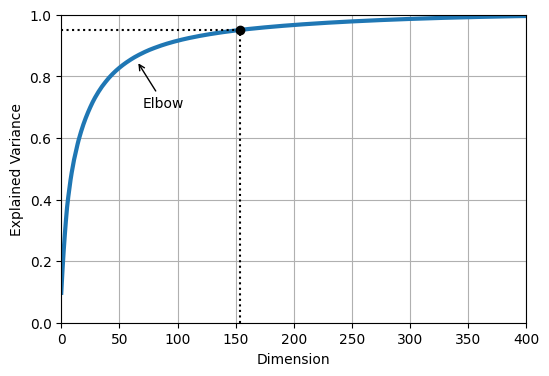

In [11]:
# ============================================================
# [10] 💡 엘보(elbow) 곡선 - 시각적으로 차원 수 결정
# ============================================================
# 누적 분산 그래프를 그려보면:
# - 초반: 가파르게 상승 (적은 차원으로 많은 정보 보존)
# - 어느 지점부터: 완만해짐 = "엘보(팔꿈치)"
#
# 👁️ 엘보 지점이 좋은 선택:
# - 차원은 적게, 분산은 많이 → 효율적 압축
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimension")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.annotate("Elbow", xy=(65, 0.85), xytext=(70, 0.7),
             arrowprops=dict(arrowstyle="->"))
plt.grid(True)
plt.show()

In [12]:
# ============================================================
# [11] 🔑 PCA + 분류기를 파이프라인으로 + 그리드 서치
# ============================================================
# 💡 차원 축소를 전처리로 사용하는 전형적인 패턴!
#
# 📌 구조:
# - Pipeline: PCA → RandomForest
# - PCA의 n_components, RF의 n_estimators 동시 탐색
# - pca__n_components: 파이프라인 이름__매개변수 형식
#
# 💡 왜 PCA를 분류기 앞에 둘까?
# - 입력 차원 감소 → 학습 속도 향상
# - 노이즈 제거 → 때로 정확도도 향상
#
# X_train[:1000]: 시간 절약을 위해 작은 부분으로 탐색
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import make_pipeline

clf = make_pipeline(PCA(random_state=42),
                    RandomForestClassifier(random_state=42))
param_distrib = {
    "pca__n_components": np.arange(10, 80),
    "randomforestclassifier__n_estimators": np.arange(50, 500)
}
rnd_search = RandomizedSearchCV(clf, param_distrib, n_iter=10, cv=3,
                                random_state=42)
rnd_search.fit(X_train[:1000], y_train[:1000])

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('pca', PCA(random_state=42)),
                                             ('randomforestclassifier',
                                              RandomForestClassifier(random_state=42))]),
                   param_distributions={'pca__n_components': array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43,
       44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60,
       6...
       414, 415, 416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426,
       427, 428, 429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439,
       440, 441, 442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452,
       453, 454, 455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465,
       466, 467, 468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478,
       479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491,
       492, 493, 494, 495, 496, 497, 498, 499])},
                   random_state=42)

In [13]:
# [12] 💡 최적 하이퍼파라미터 출력
#       PCA 차원 수와 트리 개수의 최적 조합 확인

print(rnd_search.best_params_)

{'randomforestclassifier__n_estimators': np.int64(475), 'pca__n_components': np.int64(57)}


In [14]:
# ============================================================
# [13] 🔑 inverse_transform - 압축 해제 (복원)
# ============================================================
# 💡 PCA의 흥미로운 기능:
# - X_reduced (저차원) → X_recovered (원래 차원으로 복원)
# - 완벽한 복원은 아님! (5% 정보 손실됨)
# - 손실된 정보는 "노이즈"로 해석 가능
#
# 💡 응용:
# - 노이즈 제거
# - 이상치 탐지 (복원 오차가 크면 이상치)
# - 데이터 압축
# ============================================================

X_recovered = pca.inverse_transform(X_reduced)

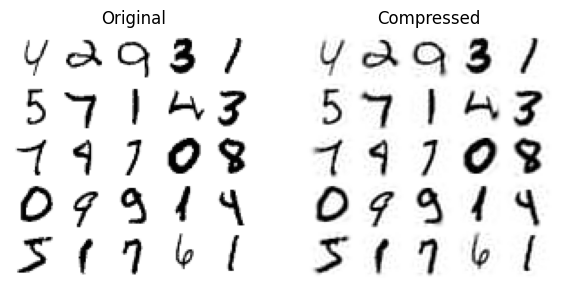

In [15]:
# ============================================================
# [14] 💡 원본 vs 압축 후 시각화
# ============================================================
# 👁️ 관찰 포인트:
# - 왼쪽 (Original): 원본 MNIST 숫자 이미지
# - 오른쪽 (Compressed): 95% 분산만 보존한 복원본
# - 숫자 인식엔 충분히 선명! 약간 흐릿한 정도
#
# 💡 이게 PCA의 신기한 점: 80% 차원 감소했는데도 모양은 거의 그대로
# ============================================================

plt.figure(figsize=(7, 4))
for idx, X in enumerate((X_train[::2100],
X_recovered[::2100])):
  plt.subplot(1, 2, idx + 1)
  plt.title(["Original", "Compressed"][idx])
  for row in range(5):
    for col in range(5):
      plt.imshow(X[row * 5 + col].reshape(28, 28),
                 cmap="binary",
                 vmin=0, vmax=255,
                 extent=(row, row + 1, col, col + 1))
      plt.axis([0, 5, 0, 5])
      plt.axis("off")

In [16]:
# ============================================================
# [15] 🔑 Randomized PCA - 더 빠른 PCA
# ============================================================
# 💡 일반 PCA vs Randomized PCA:
# - 일반: 정확한 SVD (큰 데이터에서 느림)
# - Randomized: 근사 SVD (훨씬 빠르고 정확도 비슷)
#
# svd_solver="randomized": 무작위 알고리즘 사용
# n_components << 원본 차원일 때 효과적
#
# 💡 MNIST 같이 큰 데이터셋에서 매우 유용!
# ============================================================

rnd_pca = PCA(n_components=154, svd_solver="randomized", random_state=42)
X_reduced = rnd_pca.fit_transform(X_train)

In [17]:
# ============================================================
# [16] 🔑 IncrementalPCA - 메모리 효율적 PCA
# ============================================================
# 💡 일반 PCA의 문제:
# - 전체 데이터를 메모리에 올려야 함
# - 메모리 부족 시 사용 불가
#
# 💡 IncrementalPCA의 해결책:
# - 데이터를 미니배치로 나눠 점진적으로 학습
# - np.array_split: 데이터를 n_batches개로 분할
# - partial_fit: 각 배치로 조금씩 학습 (SGD의 GD 버전과 비슷!)
#
# 사용 사례: 메모리에 안 들어가는 거대한 데이터셋
# ============================================================

from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)
for X_batch in np.array_split(X_train, n_batches):
  inc_pca.partial_fit(X_batch)

X_reduces = inc_pca.transform(X_train)

In [18]:
# ============================================================
# [17] 💡 메모리 매핑(memory map) - 디스크 기반 데이터 처리
# ============================================================
# 💡 np.memmap이란?
# - 거대한 배열을 디스크에 저장하고 일부만 메모리로 로드
# - 메모리에 안 들어가는 데이터를 다룰 때 핵심 기법!
#
# - mode='write': 쓰기 모드로 새 파일 생성
# - dtype='float32': 데이터 타입
# - flush(): 메모리 변경사항을 디스크에 즉시 반영
# ============================================================

filename = "my_mnist.mmap"
X_mmap = np.memmap(filename, dtype='float32', mode='write', shape=X_train.shape)
X_mmap[:] = X_train
X_mmap.flush()

In [19]:
# [18] 💡 memmap 데이터를 IncrementalPCA로 학습
#       - mode='readonly': 읽기 전용 (안전)
#       - 디스크에서 직접 배치 단위로 읽어와 처리
#       → 메모리 사용량 극소화!

X_mmap = np.memmap(filename, dtype="float32", mode="readonly").reshape(-1, 784)
batch_size = X_mmap.shape[0] // n_batches
inc_pca = IncrementalPCA(n_components=154, batch_size=batch_size)
inc_pca.fit(X_mmap)

IncrementalPCA(batch_size=600, n_components=154)

In [20]:
# ============================================================
# [19] 🔑 Johnson-Lindenstrauss 정리 - 랜덤 투영의 수학적 보장
# ============================================================
# 💡 놀라운 정리:
# "고차원 데이터를 무작위 행렬로 곱해도 거리가 잘 보존된다!"
#
# 📌 johnson_lindenstrauss_min_dim:
# - m: 샘플 수
# - eps: 허용 왜곡 (0.1 = 거리가 10% 이내로 왜곡)
# - 반환: 필요한 최소 차원 d
#
# 💡 5000개 샘플, 10% 왜곡 허용 → 약 7300차원만 있으면 충분!
# (원래가 10만 차원이어도)
# ============================================================

from sklearn.random_projection import johnson_lindenstrauss_min_dim
m, e = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(m, eps=e)
d

np.int64(7300)

In [21]:
# ============================================================
# [20] 🔑 랜덤 투영 직접 구현 - 정말 단순함!
# ============================================================
# 💡 알고리즘:
# 1. 가우시안 분포로 무작위 행렬 P 생성 (d × n)
# 2. /sqrt(d): 정규화
# 3. X @ P^T: 단순 행렬곱!
#
# 💡 PCA보다 빠르고 메모리 효율적
# - PCA는 SVD 계산 필요 (O(min(m·n², m²·n)))
# - 랜덤 투영은 그냥 행렬곱! (O(m·n·d))
# ============================================================

n = 20_000
np.random.seed(42)
P = np.random.randn(d, n) / np.sqrt(d)

X = np.random.randn(m, n)
X_reduced = X @ P.T

In [22]:
# [21] 💡 사이킷런의 GaussianRandomProjection
#       [20]을 한 줄로!
#       eps로 자동으로 적절한 차원 수 결정

from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=e, random_state=42)
X_reduced = gaussian_rnd_proj.fit_transform(X)

In [23]:
# ============================================================
# [22] 💡 랜덤 투영도 복원 가능
# ============================================================
# - np.linalg.pinv: 의사 역행렬(pseudoinverse)
# - 정확한 역변환은 아니지만 근사 복원 가능
# - 정보 손실은 있지만 거리는 잘 보존됨
# ============================================================

components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)
X_recovered = X_reduced @ components_pinv.T

In [24]:
# ============================================================
# [23] 🔑 LLE (Locally Linear Embedding) - 비선형 차원 축소
# ============================================================
# 💡 PCA vs LLE:
# - PCA: 선형 차원 축소 (직선 평면으로 투영)
# - LLE: 비선형 차원 축소 (구부러진 매니폴드를 펼침)
#
# 📌 스위스롤 데이터:
# - 3D 공간에서 돌돌 말려있는 데이터
# - 사실은 2D 매니폴드 (펴면 평면!)
# - PCA로는 못 펴고 그냥 평면 투영 → 잘못된 결과
# - LLE는 "각 점의 이웃 관계를 보존"하며 펼침!
#
# 매개변수:
# - n_components=2: 2D로 축소
# - n_neighbors=10: 각 점의 이웃 10개를 고려
# ============================================================

from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_unrolled = lle.fit_transform(X_swiss)

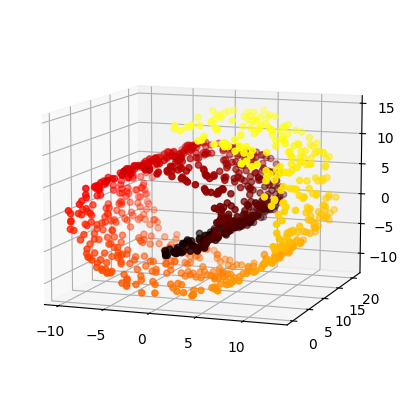

In [25]:
# [24] 💡 원본 스위스롤 시각화 (3D)
#       돌돌 말린 종이 모양 - 색상은 매니폴드 위치 t값

from matplotlib.colors import ListedColormap

darker_hot = ListedColormap(plt.cm.hot(np.linspace(0, 0.8, 256)))
axes = [-11.5, 14, -2, 23, -12, 15]

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2],
           c=t, cmap=darker_hot)
ax.view_init(10, -70)

plt.show()

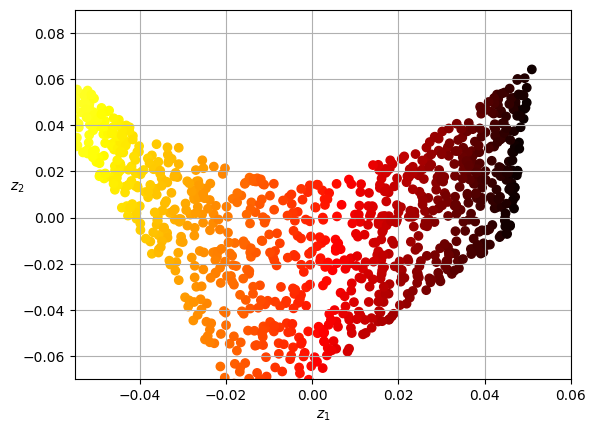

In [26]:
# [25] 💡 LLE로 펼친 결과 (2D)
#       👁️ 마법 같은 일! 돌돌 말려있던 게 평면처럼 펴짐
#       색상 그라데이션이 부드럽게 이어짐 → 이웃 관계 보존됨!

plt.scatter(X_unrolled[:, 0], X_unrolled[:, 1],
            c=t, cmap=darker_hot)
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.axis([-0.055, 0.060, -0.070, 0.090])
plt.grid(True)

plt.show()

In [27]:
# ============================================================
# [26] 🎓 차원 축소의 실전 효과 확인 - MNIST 분류
# ============================================================
# 💡 실험 계획:
# 1. 원본 (784차원) RandomForest 학습 시간/정확도
# 2. PCA 적용 (약 154차원) RandomForest 학습 시간/정확도
# 3. SGD에서도 같은 비교
#
# 차원 축소가 실제로 도움 되는지 확인!
# ============================================================

from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser='auto')
X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

In [28]:
# [27] 💡 원본 데이터로 RandomForest 학습 (시간 측정!)
#       %time: 셀 실행 시간 측정
#       랜덤 포레스트는 의외로 많은 특성을 잘 처리해서 별로 느려지지 않음

from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)
%time rnd_clf.fit(X_train, y_train)

CPU times: user 50.2 s, sys: 66.1 ms, total: 50.3 s
Wall time: 50.6 s


RandomForestClassifier(random_state=42)

In [29]:
# [28] 원본 RandomForest 정확도 (기준선)

from sklearn.metrics import accuracy_score

y_pred = rnd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9705

In [30]:
# [29] 💡 PCA로 95% 분산 보존하며 차원 축소
#       784 → 약 154차원 (80% 압축!)

from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_reduced = pca.fit_transform(X_train)

In [31]:
# ============================================================
# [30] ⚠️ 흥미로운 사실: RandomForest는 PCA 후 더 느려질 수도!
# ============================================================
# 💡 왜?
# - 트리는 원본 특성을 직관적으로 분할 가능
# - PCA 후 특성은 "여러 픽셀의 조합" → 더 복잡한 분할 필요
# - 트리는 차원 축소 효과를 크게 못 봄
#
# 💡 결론: 모든 모델이 PCA로 빨라지진 않음!
# ============================================================

rnd_clf_with_pca=RandomForestClassifier(n_estimators=100, random_state=42)
%time rnd_clf_with_pca.fit(X_train_reduced, y_train)

CPU times: user 2min 37s, sys: 167 ms, total: 2min 37s
Wall time: 2min 38s


RandomForestClassifier(random_state=42)

In [32]:
# [31] 💡 PCA 적용 후 정확도 - 보통 약간 낮아짐 (정보 손실)
#       trade-off: 시간 vs 정확도

X_test_reduced = pca.transform(X_test)

y_pred = rnd_clf_with_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred)

0.9488

In [33]:
# [32] 💡 SGDClassifier로 학습 - 선형 모델
#       선형 모델은 차원 축소 효과를 크게 봄!

from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
%time sgd_clf.fit(X_train, y_train)

CPU times: user 2min 49s, sys: 202 ms, total: 2min 49s
Wall time: 2min 50s


SGDClassifier(random_state=42)

In [34]:
# [33] SGD 원본 정확도

y_pred = sgd_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.874

In [35]:
# ============================================================
# [34] ✅ SGD + PCA의 진가!
# ============================================================
# 💡 선형 모델은 차원 축소로 크게 빨라짐:
# - 파라미터 수가 차원에 비례 (784 → 154 = 5배 감소)
# - 그래디언트 계산이 훨씬 빠름
#
# 💡 차원 축소가 효과적인 모델:
# ✅ 선형 모델 (SGD, LogisticRegression)
# ✅ 거리 기반 (KNN, SVM with RBF)
# ❌ 트리 기반 (Random Forest, GBM)
# ============================================================

sgd_clf_with_pca = SGDClassifier(random_state=42)
%time sgd_clf_with_pca.fit(X_train_reduced, y_train)

CPU times: user 41.6 s, sys: 36.2 ms, total: 41.6 s
Wall time: 41.7 s


SGDClassifier(random_state=42)

In [36]:
# [35] SGD + PCA 정확도 - 원본과 비슷하거나 약간 다름

y_pred = sgd_clf_with_pca.predict(X_test_reduced)
accuracy_score(y_test, y_pred)

0.8959

In [37]:
# ============================================================
# [36] 🔑 t-SNE - 시각화 최강자!
# ============================================================
# 💡 t-SNE란?
# - 고차원 데이터를 2D/3D로 시각화하는 데 특화
# - "비슷한 샘플은 가깝게, 다른 샘플은 멀게" 배치
# - 비선형 차원 축소
#
# ⚠️ 주의사항:
# - 매우 느림 → 5000개로 제한
# - 시각화 전용 (분류 모델 입력으로 쓰지 말 것!)
# - 매번 결과가 약간씩 다름 (random_state로 고정)
# - 클러스터 크기/거리는 절대적 의미 없음 (상대적 관계만)
#
# 매개변수:
# - n_components=2: 2D 시각화
# - init="random": 초기값
# - learning_rate="auto": 자동 학습률
# ============================================================

X_sample, y_sample = X_train[:5000], y_train[:5000]

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init="random", learning_rate="auto",
            random_state=42)
X_reduced = tsne.fit_transform(X_sample)

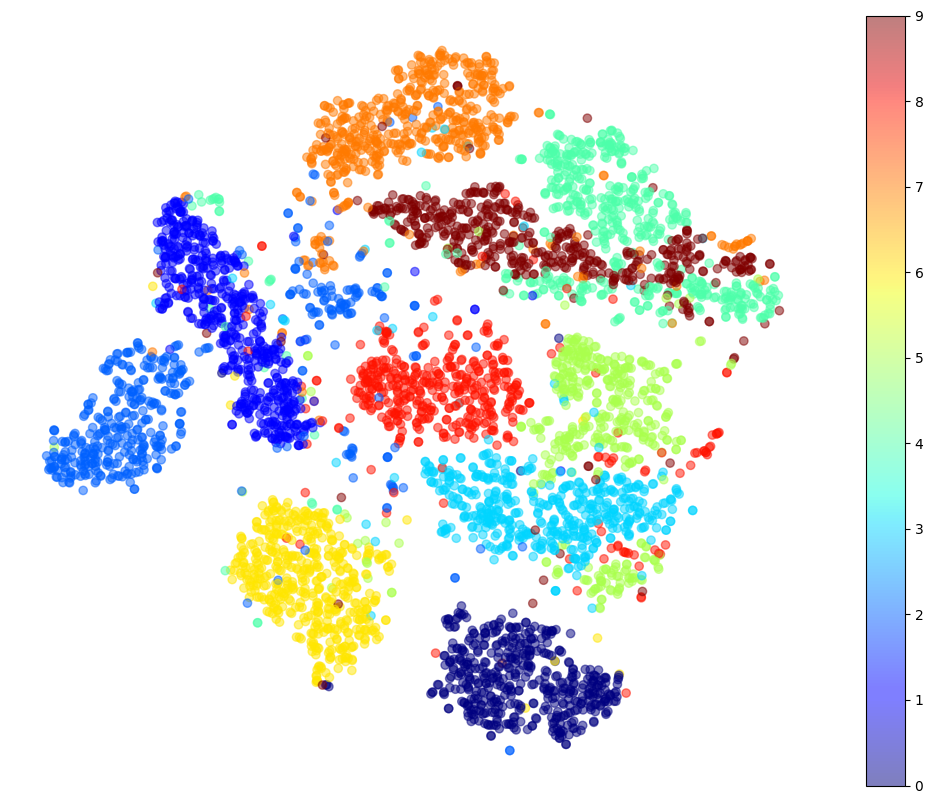

In [38]:
# ============================================================
# [37] 💡 t-SNE 결과 시각화 - 시각적 충격!
# ============================================================
# 👁️ MNIST 숫자들이 자연스럽게 클러스터를 형성:
# - 같은 숫자끼리 모임
# - 비슷한 숫자(예: 4와 9, 3과 5)는 가까이
# - 완전 다른 숫자는 멀리
#
# 💡 t-SNE는 레이블 정보 없이도(비지도) 이렇게 분리!
# → 데이터의 본질적 구조를 발견하는 강력한 도구
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(13, 10))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1],
            c=y_sample.astype(np.int8), cmap="jet", alpha=0.5)
plt.axis('off')
plt.colorbar()
plt.show()

In [39]:
# ============================================================
# [38] 💡 멋진 시각화 함수 - 실제 이미지를 산점도 위에 표시
# ============================================================
# - MinMaxScaler: 좌표를 0~1 범위로 정규화
# - AnnotationBbox + OffsetImage: matplotlib에 이미지 박스 추가
# - min_distance: 가까운 점들끼리 겹치지 않도록 거리 제한
#
# 효과: 산점도의 각 점 위에 실제 숫자 이미지가 표시됨!
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage


def plot_digits(X, y, min_distance=0.04, images=None, figsize=(13, 10)):
    X_normalized = MinMaxScaler().fit_transform(X)
    neighbors = np.array([[10., 10.]])
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    digits = np.unique(y)

    for digit in digits:
        plt.scatter(
            X_normalized[y == digit, 0],
            X_normalized[y == digit, 1],
            c=[cmap(float(digit) / 9)],
            alpha=0.5
        )

    plt.axis("off")
    ax = plt.gca()

    for index, image_coord in enumerate(X_normalized):
        closest_distance = np.linalg.norm(neighbors - image_coord, axis=1).min()

        if closest_distance > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]

            if images is None:
                plt.text(
                    image_coord[0],
                    image_coord[1],
                    str(int(y[index])),
                    color=cmap(float(y[index]) / 9),
                    fontdict={"weight": "bold", "size": 16}
                )
            else:
                image = images[index].reshape(28, 28)
                imagebox = AnnotationBbox(
                    OffsetImage(image, cmap="binary"),
                    image_coord
                )
                ax.add_artist(imagebox)

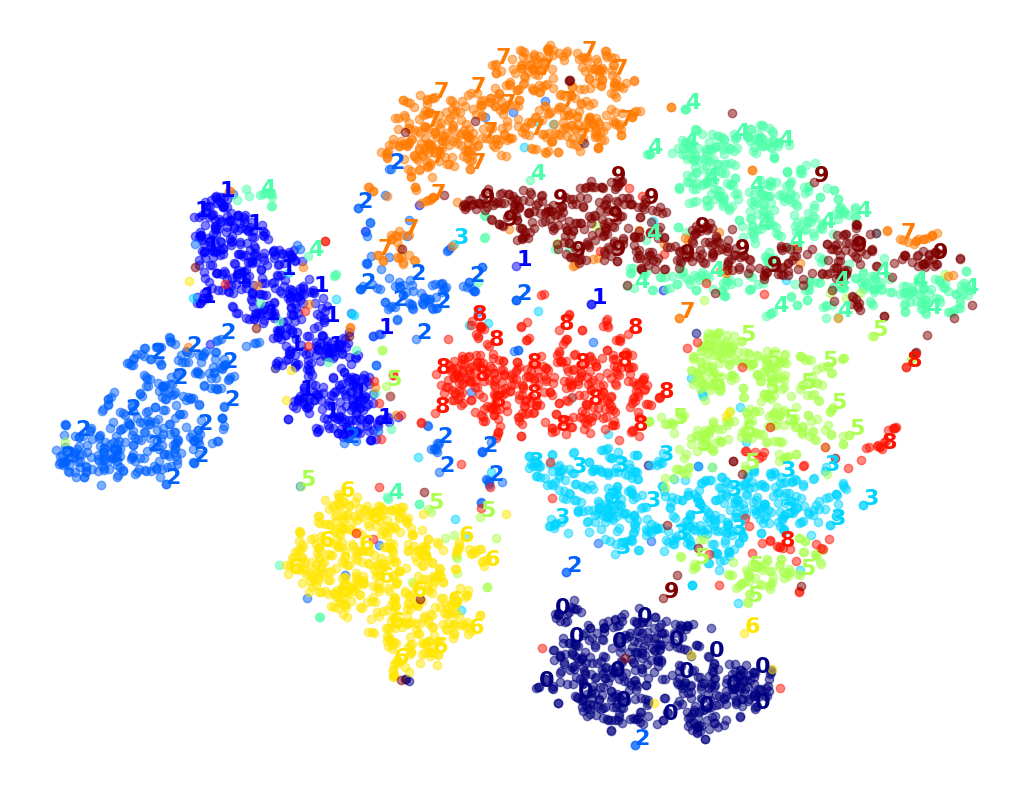

In [40]:
# [39] 숫자 텍스트 버전 시각화

plot_digits(X_reduced, y_sample)

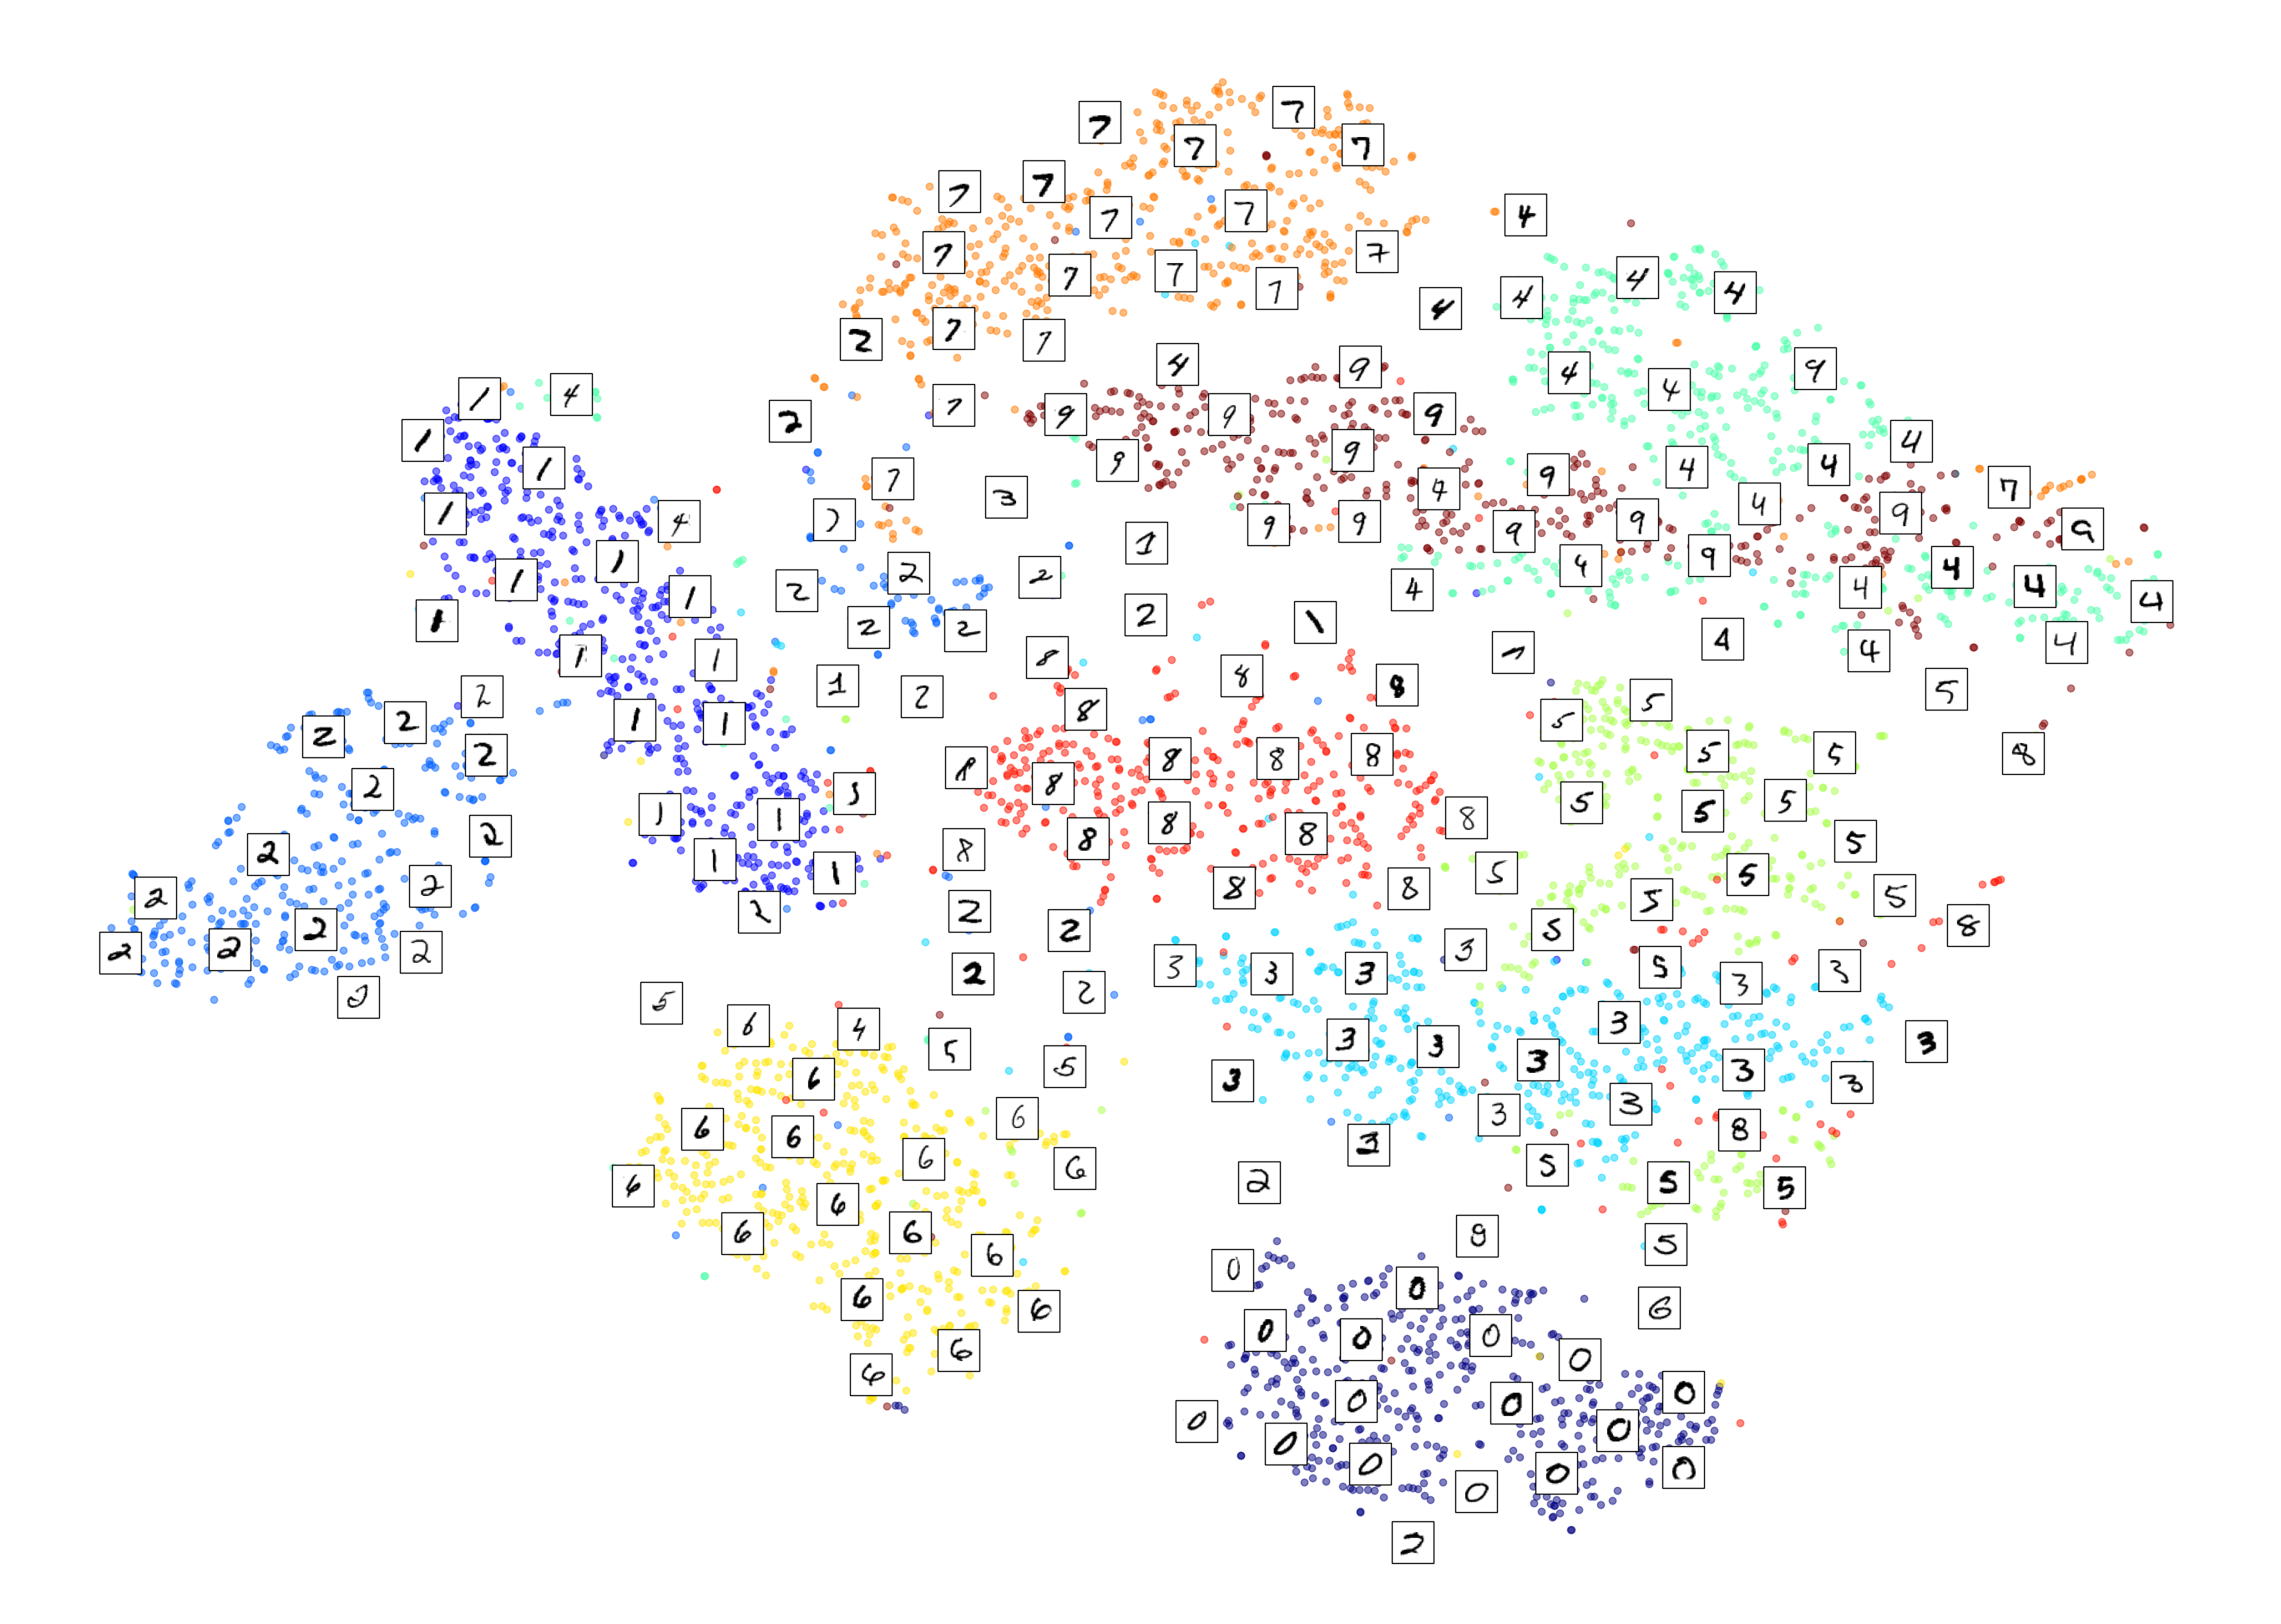

In [41]:
# [40] 🎯 진짜 이미지 버전 시각화 - 가장 멋진 결과!
#       MNIST 숫자가 2D 평면에 펼쳐진 모습
#       비슷한 모양의 숫자들이 자연스럽게 모임

plot_digits(X_reduced, y_sample, images=X_sample, figsize=(35, 25))